# Olivia Weihmuller
<h1 align="center">TS1: Síntesis y operaciones de señales</h1>

#### En este trabajo practico se presenta el diseno, síntesis y análisis entre diversas senales discretas, desde senales senoidales puras hasta secuencias de ruido con propiedades estocasticas controladas mediante su valor medio y su varianza. Se estudio la diferencia espectral de estas senales, pudiendo diferenciar los distintos tipos de senales. Asimismo, se verifica experimentalmente el Teorema de Parseval, demostrando la conservacion de la potencia y la energia por medio de calculos de la senal en el dominio del tiempo contra la transformada de Fourier en el dominio de la frecuencia.
#### Para este trabajo, además de analizar la FFT en la escala lineal común (en Volts), también se sumó un gráfico en escala logarítmica usando decibeles (dB) con referencia a $1\text{ W}$. Esto es clave porque las señales reales tienen lo que llamamos un gran 'rango dinámico'. Al pasarlo a decibeles, se normalizó el espectro para eliminar los factores de escala de la FFT. Se puede analizar mejor, sin que los picos grandes 'tapen' a los picos mas débiles 

Para todas las senales se utilizó 1000 muestras (N), una frecuencia de muestreo de 20KHz y la frecuencia de la señal de 2KHz.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.signal as sig

N =1000
fs = 20000 #Hz
f0 = 2000 # Hz
tt = np.arange(N) / fs
freqs = np.fft.fftfreq(N, d=1/fs)
mitad_freqs = freqs[:N//2]

def mi_funcion_sen( amp = 1, dc = 0, ff = 1, ph=0, N = N, fs = fs):
     #valor medio de una senal = dc (si no lo pasa toma x defecto el 0)

    #amp= np.sqrt(2)
    nn = np.arange (N) 
    xx = amp * np.sin (2 * np.pi * ff * nn/fs + ph) +dc
    tt = nn/fs  # tiempo de cada muestra
    
   # hasta acá
    return(tt, xx)

# calcula fft y grafica
def analizar_y_graficar (senal, titulo):
   fft_senal = np.fft.fft(senal) 
   # nos da numeros complejos
   
   mod_fft = np.abs(fft_senal)[:N//2]
   
   # PARSEVAL, relaciona la potencia o energia de la senal en el tiempo  con la frecuencia
   # Fisicamente la potencia y energia son numero reales, al clacular el modulo se nos va la parte imaginaria
   pot_fft = np.sum(np.abs(fft_senal)**2)/(N**2)
   pot_tiempo = np.sum(np.abs(senal)**2)/N

    # potencia POR BIN, para el eje de frecuencias completo
   pot_bin = (np.abs(fft_senal)**2) / (N**2)   # array de N valores
   pot_bin = pot_bin[:N//2]                 # me quedo con la mitad, como en mod_fft

   # paso a dB, referencia 1 W -> 0 dB
   eps = 1e-15  # para evitar log(0) = -inf
   pot_db = 10 * np.log10(pot_bin + eps)
   
   print(f"--- {titulo} ---")
   print(f"Potencia calculada en el Tiempo: {pot_tiempo:.6f} W")
   print(f"Potencia calculada en Frecuencia: {pot_fft:.6f} W")
   print(f"Diferencia: {abs(pot_tiempo - pot_fft):.2e}")
   print("-" * 40)
#Grafico 1
   fig, ax = plt.subplots(figsize=(10, 3.5))
   ax.plot(mitad_freqs, mod_fft, color='b')
   ax.set_title(f"Modulo FFT - {titulo}")
   ax.set_xlabel("Frecuencia [Hz]")
   ax.set_ylabel("Amplitud [V]")
   plt.tight_layout()
   plt.show()


# Grafico 2, en dB con referencia 1W
   fig, ax = plt.subplots(figsize=(10, 3.5))
   ax.plot(mitad_freqs, pot_db, color='r')
   ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # marca la línea de 0 dB
   ax.set_title(f"Espectro en dB (ref. 1W) - {titulo}")
   ax.set_xlabel("Frecuencia [Hz]")
   ax.set_ylabel("Potencia [dB]")
   plt.tight_layout()
   plt.show()

Se disenaron dos funciones. La primera se encarga de sintetizar una señal senoidal parametrizable. La segunda función tiene como objetivo analizar espectralmente la senal generada: calcula la Transformada de Fourier (FFT), extrae su modulo espectral para su posterior visualizacion gráfica, y evalua el Teorema de Parseval comparando la potencia media calculada desde el dominio del tiempo y desde el dominio de frecuencia.

--- Señal 1: Senoidal ---
Potencia calculada en el Tiempo: 0.500000 W
Potencia calculada en Frecuencia: 0.500000 W
Diferencia: 1.11e-16
----------------------------------------


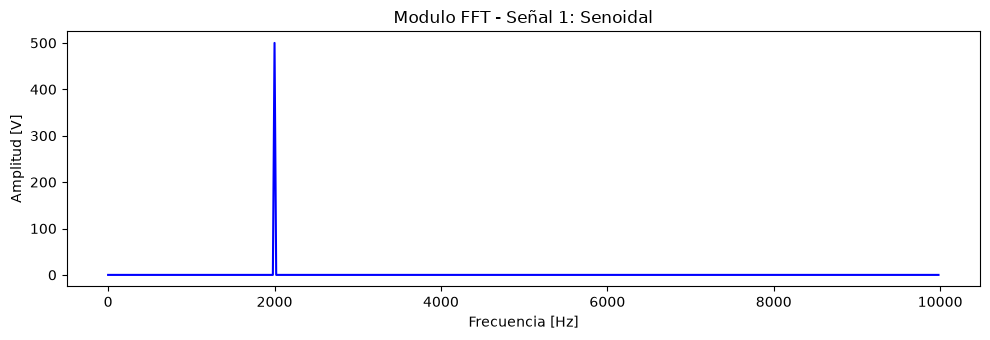

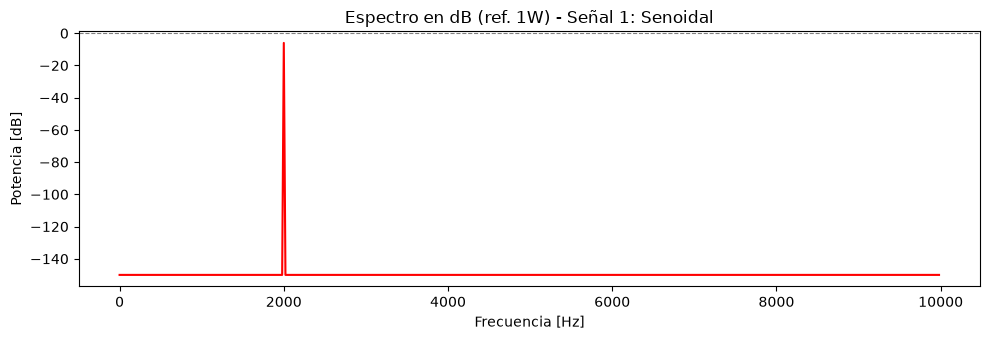

In [38]:
#%% 1 SENAL SENOIDAL 

_,s1 = mi_funcion_sen(amp=1, dc=0, ph=0, ff= f0, N=N, fs = fs)

analizar_y_graficar(s1, "Señal 1: Senoidal")


La primer senal analizada es una sinusoidal de 2 KHz que tiene 10 puntos por período. Se puede ver que en la figura de 'Modulo FFT- Senal 1' se obtuvo un pico en la frecuencia 2000 Hz con una amplitud de 500, este pico emula la delta Kronecker discreta en frecuencia. Al pasar este espectro a decibeles nos permite confirmar que es una señal pura, debido a que no aparece ninguna otra frecuencia con energía en el fondo.

--- Señal 2: Senoidal con desafase de pi/2 ---
Potencia calculada en el Tiempo: 2.000000 W
Potencia calculada en Frecuencia: 2.000000 W
Diferencia: 8.88e-16
----------------------------------------


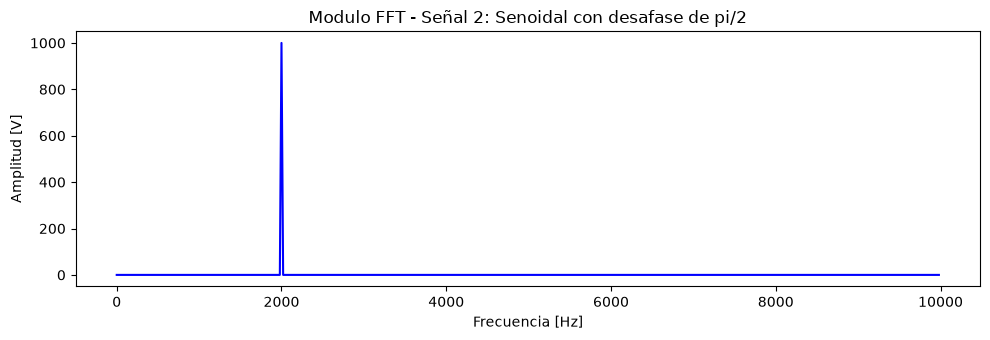

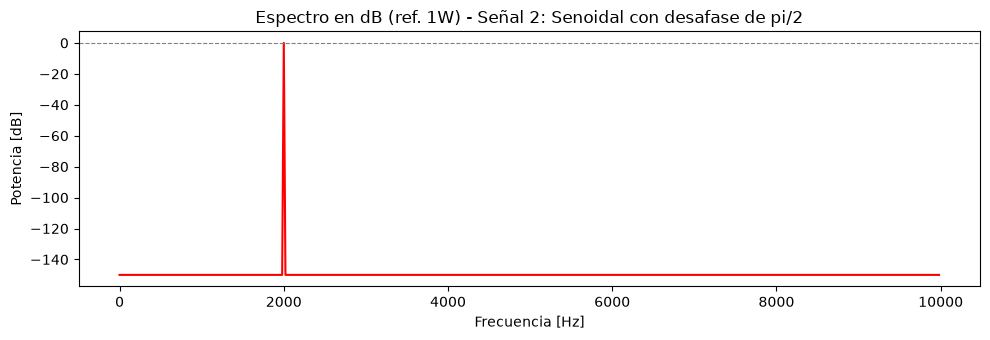

In [39]:
#%% SENAL 2 SENOIDAL

_,s2 = mi_funcion_sen(amp=2, dc=0, ph=(np.pi/2), ff= f0, N=N, fs = fs)

analizar_y_graficar(s2, "Señal 2: Senoidal con desafase de pi/2")

Para la segunda senal se volvio a analizar una senoidal, pero desfasada en $\pi/2$ y con $2\text{ W}$ de potencia media (lo que genera que amplitud sea $A = 2$, el doble de la anterior). La consecuencia de esta variacion de datos se manifiesta en que el pico espectral es exactamente del doble del tamano que el de la señal anterior, debido a que su amplitud es el doble de la anterior (puede ver en la figura Modulo- FFT Senal 2). El desafasaje entre estas dos señales no se evidencia en este gráfico porque estamos representando unicamente el módulo de la FFT, donde la fase no altera la forma del gráfico. (La fase se evidencia en el grafico de fase). Al pasar este espectro a decibeles (en la figura Espectro en dB - Senal 2), el pico de la senal se ubica justo en los 0 dB. Además, este gráfico permite comprobar que el desfasaje de $\pi/2$ altera la parte compleja de la FFT pero no afecta en absoluto al módulo ni a la potencia de la señal. Y nuevamente se puede comprobar que es una senal pura.

--- Señal 3: Ruido Gaussiano ---
Potencia calculada en el Tiempo: 0.108028 W
Potencia calculada en Frecuencia: 0.108028 W
Diferencia: 1.39e-17
----------------------------------------


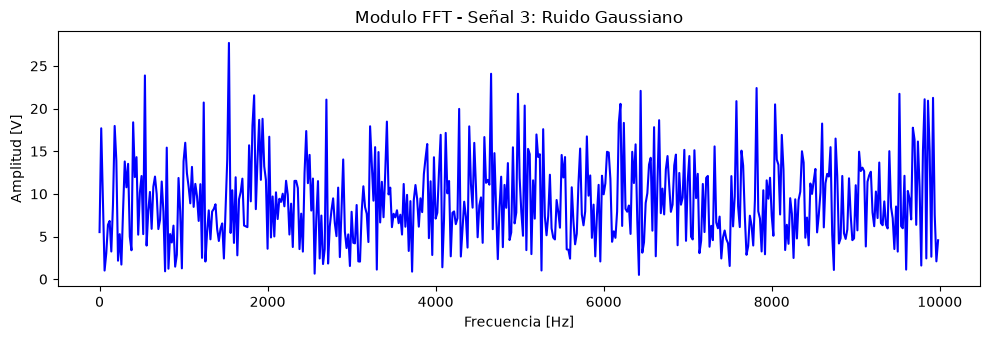

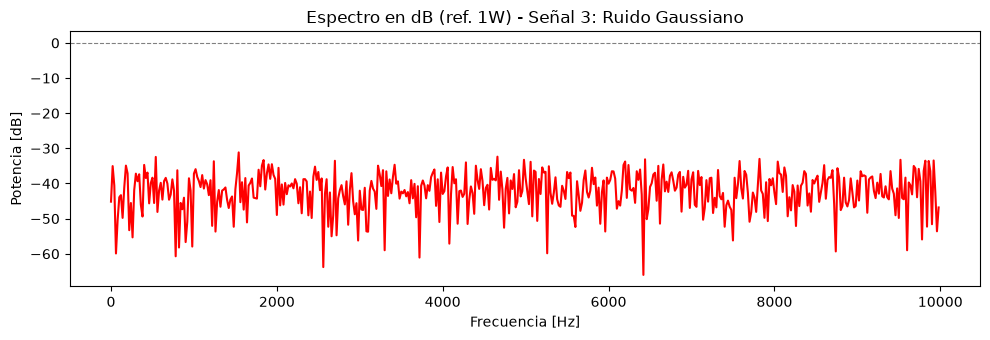

In [40]:
#%% SENAL 3

rng = np.random.default_rng()

s3 = rng.normal(loc = 0, scale = np.sqrt(0.1), size = N)
# es la media, el valor medio (DC)
# scale, es la desviacion estandar (Sin el cuadrado)
# size, numero de muestras

analizar_y_graficar(s3, "Señal 3: Ruido Gaussiano")

--- Senal 4: Ruido Uniforme ---
Potencia calculada en el Tiempo: 0.097223 W
Potencia calculada en Frecuencia: 0.097223 W
Diferencia: 1.39e-17
----------------------------------------


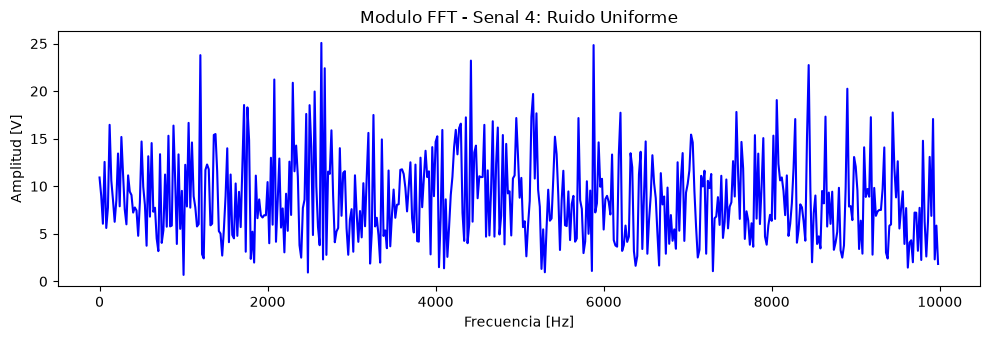

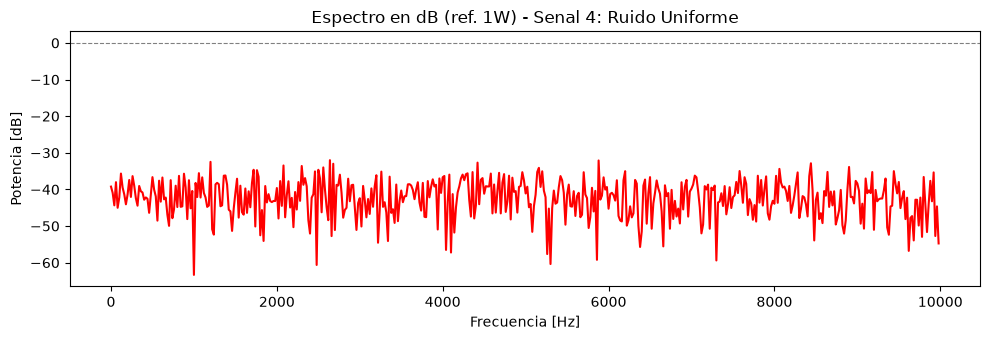

In [41]:
#%% SENAL 4

# DC = 0 y Varianza = 0.1 W

s4 = rng.uniform(low=-np.sqrt(0.3), high=np.sqrt(0.3),size= N)

# low y high -> [] (intervalo), para que el valor medio sea 0 este intervalo debe ser simetrico

analizar_y_graficar(s4, "Senal 4: Ruido Uniforme")

Para la tercera y cuarta señal se analizaron dos tipos de ruidos con valor medio cero (DC = 0 V) y varianza de 0.1 W: el primero con distribución normal (Gaussiana) y el segundo con distribución uniforme. Si miramos los gráficos de sus FFT (figura de Modulo de FFT - Senal 3 y figura de Modulo de FFT - Senal 4), ambos tienen un espectro irregular, con numerosos picos distribuidos a lo largo de todo el eje de frecuencias. Esto pasa porque ambos ruidos son "blancos", lo que significa que su potencia se distribuye de manera constante y uniforme por todo el espectro.
La diferencia entre estas dos señales no se ve en la FFT, sino en cómo se comportan en el dominio del tiempo y sus probabilidades:
En el ruido uniforme (Señal 4), los valores de voltaje están limitados dentro del rango simétrico de $[-\sqrt{0.3}, \sqrt{0.3}]$. Todos los valores dentro de ese límite tienen exactamente la misma probabilidad de salir, y es imposible que aparezca una muestra fuera de ahí.
En el ruido Gaussiano (Señal 3), los valores siguen una campana de Gauss donde estar cerca de 0 V es lo más probable, pero teóricamente podría aparecer una muestra con un valor de voltaje extremadamente alto o bajo. 
En el gráfico de frecuencia esta diferencia temporal desaparece porque la FFT solo nos muestra el módulo (la amplitud) de las frecuencias. Como ambos ruidos son 'blancos' y tienen exactamente la misma potencia media de 0.1 W, ambos distribuyen de forma constante su energía en frecuencia, mostrándose en el gráfico como picos aleatorios muy similares debido a que la transformada de casi cualquier ruido con un gran número de muestras tiende a aproximarse a una distribución gaussiana, haciendo que sus gráficos de Fourier sean sumamente parecidos a simple vista.
Al pasarlos a decibeles, normalizamos para analizar con mucha más resolución. En la escala en dB se puede apreciar claramente que, más allá de las oscilaciones aleatorias de los picos, el nivel de potencia promedio se mantiene constante y es el mismo para ambos ruidos en todo el espectro, confirmando que la energía se distribuye de forma idéntica sin importar si el ruido es uniforme o gaussiano en el tiempo.

--- Senal 5: Pulso rectangular ---
Potencia calculada en el Tiempo: 1.000000 W
Potencia calculada en Frecuencia: 1.000000 W
Diferencia: 2.22e-16
----------------------------------------


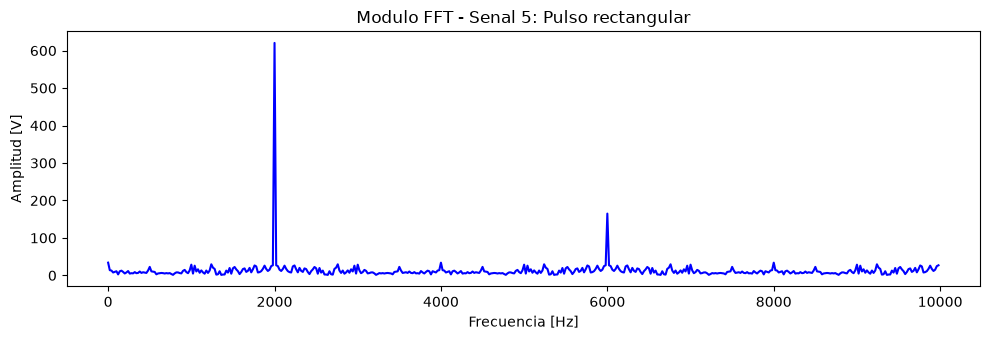

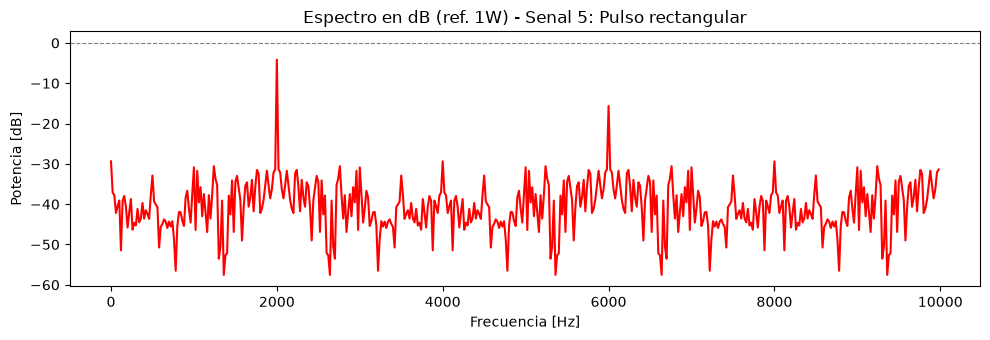

In [42]:
#%% SENAL 5

s5 = signal.square(2*np.pi*f0*tt, duty = 0.5)

analizar_y_graficar(s5, "Senal 5: Pulso rectangular")


La última senal analizada es un pulso rectangular. En este gráfico (en la figura Modulo FFT - Senal 5) se pueden visualizar varios picos correspondientes a la frecuencia fundamental y sus armónicos. Es importante aclarar que la frecuencia de Nyquist es 10 kHz ($f_{\text{Nyquist}} = f_s / 2$), por lo que solo se pueden observar de forma correcta los picos que queden por debajo de ese límite. Observando el gráfico, se ve el pico mas alto en 2000 Hz (la fundamental) y otro en 6000 Hz (que corresponde a un armónico).
Se paso a decibeles el grafico, es decir lo normalizamos, en la figura de Espectro en dB - Senal 5. Esto nos permite ver con más resolución la silueta de la función sinc periódica que describe al pulso, haciendo completamente visible la caída lenta de sus lóbulos secundarios (que disminuyen en proporción a $1/f$) y que antes no se podian apreciar de manera correcta.


--- Senal 6: Bonus - sawtooth ---
Potencia calculada en el Tiempo: 0.340000 W
Potencia calculada en Frecuencia: 0.340000 W
Diferencia: 0.00e+00
----------------------------------------


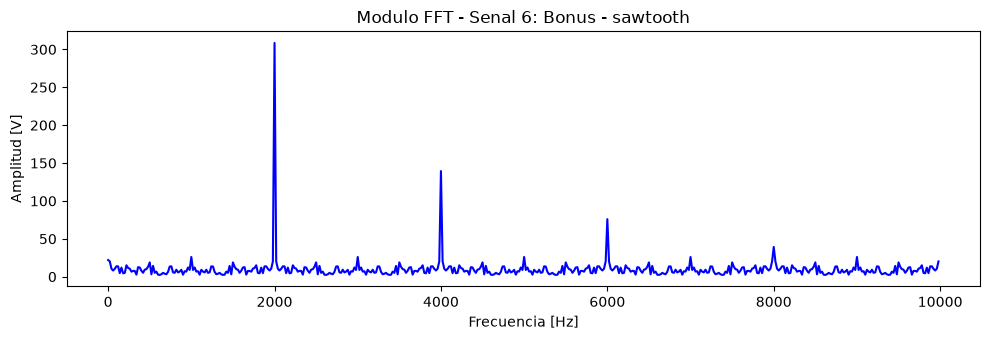

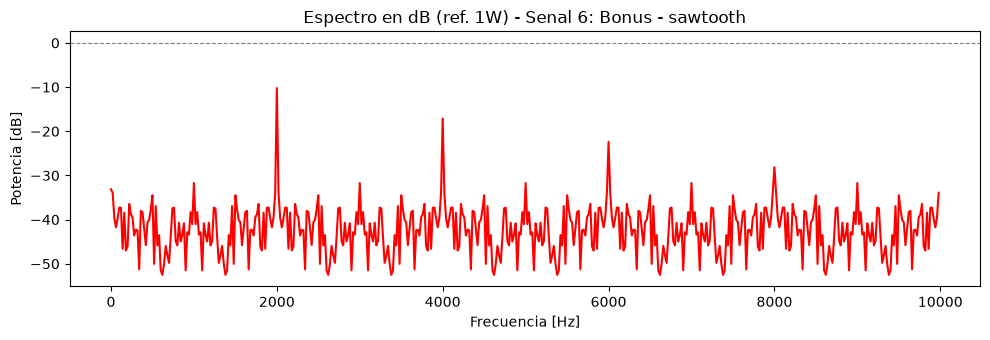

In [43]:
#%% SENAL 6 (BONUS)

s6 = signal.sawtooth(2*np.pi*f0*tt)

analizar_y_graficar(s6, "Senal 6: Bonus - sawtooth")


Como señal extra se analizó una senal de sawtooth. Al mirar su FFT, se observa que —a diferencia del pulso rectangular— esta señal sí presenta armónicos tanto pares como impares (picos en 2000, 4000, 6000 y 8000 Hz)

#### Conclusion
Este trabajo práctico nos permitió analizar y contrastar el comportamiento de diferentes señales discretas de $N=1000$ muestras en los dominios del tiempo y de la frecuencia1. Al visualizar el módulo de la FFT, confirmamos que las señales sinusoidales concentran toda su energía en un pico limpio y que duplicar la potencia media a 2 W (lo que implica duplicar la amplitud) genera un pico espectral exactamente del doble de altura, mientras que el desfasaje de $\pi/2$ no altera para nada el módulo de la transformada. Por otro lado, los ruidos blanco gaussiano y uniforme de potencia 0.1 W distribuyen de forma constante su energía en frecuencia, mostrándose en el gráfico como picos aleatorios muy similar debido a que la transformada de casi cualquier ruido con un gran número de muestras tiende a aproximarse a una distribución gaussiana. Para el pulso rectangular de 2 kHz (con ciclo de actividad del 50%), la FFT evidenció un espectro con componentes únicamente en la frecuencia fundamental y sus armónicos impares, viéndose limitados de forma estricta por la frecuencia de Nyquist ($f_s/2$) para evitar el aliasing. 
Luego, pasamos los espectros a decibeles para normalizar las gráficas y eliminar los factores de escala absolutos de la FFT. Esto nos permitió analizar con más resolución los armónicos secundarios y el piso de ruido que antes quedaban invisibles.
Finalmente, se comprobo numéricamente el Teorema de Parseval, validando que la energía sumada muestra a muestra en el tiempo equivale de forma idéntica a la suma de las magnitudes de la transformada al cuadrado ponderada por el factor de escala $1/N$.